# The ZigZag indicator — a quantitative teardown 🔬
### Mechanical threshold ZigZag on 5 indices · confirmed-up-leg forward returns (no repaint) · one-sample HAC *t* · a drift-matched random-entry baseline · a relabelled-leg geometry placebo · costs · a synthetic planted-turn control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![ZigZag_tradable%3F: Busted](https://img.shields.io/badge/ZigZag_tradable%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **turn** from the **drift** (and from the **repaint**): an upward-trending index makes *any* dip-buy look good, and the finished ZigZag peeks at the future, so the only meaningful test is confirmed-leg-vs-random plus a placebo that destroys the up/down structure while preserving the marginals.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. ZigZag threshold pct=5% with an explicit confirmation (repaint) lag; entry is the **next close** (one documented lag). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from zigzag_indicator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real zigzag cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 428, 'pct': 0.05, 'fp_spy': '4cb5244f3990', 'h5': (5, 428, -5.9, 56, -0.32, 17.8, -23.7, -7.9, -1.04, 0.298), 'h10': (10, 428, 39.6, 61, 1.62, 29.0, 10.6, 37.6, 0.34, 0.734), 'h20': (20, 428, 111.9, 64, 2.87, 53.4, 58.5, 109.9, 1.33, 0.183), 'h60': (60, 423, 370.3, 66, 4.35, 222.2, 148.1, 368.3, 2.12, 0.034), 'per': [('SPY', 78, 94.3, 0.98, 58.9, 35.4), ('QQQ', 91, 152.0, 1.56, 87.9, 64.1), ('IWM', 115, 139.2, 1.65, 36.5, 102.7), ('DIA', 70, 97.0, 1.25, 50.6, 46.4), ('GLD', 74, 52.9, 1.13, 34.6, 18.3)], 'placebo': (94.3, 0.645, 500), 'syn': [(0.0, 57, -1.0, 51, -0.01), (0.4, 52, 435.0, 81, 5.37)]}


real zigzag cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Confirmed up-leg vs a **drift-matched random** baseline: Δ = -24/+11/+58 bps at 5/10/20d, Welch *t* = -1.04/+0.34/+1.33 (all *p* > 0.18). Only 60d clears 2 (Welch *t* = +2.12, *p* = 0.034). |
| **Tradability** | `MIRAGE` | The strong one-sample t's (20d t = 2.87, 60d t = 4.35) are **mostly beta**; the lone 60d blip is geometry-independent slow drift (placebo below). No residual edge to scale. |
| **ZigZag tradable?** | `BUSTED` | Relabelling which confirmations are 'lows' (relabelled-leg placebo) leaves the result intact: **p = 0.65** of nonsense-label runs match or beat the real one. The up/down structure isn't load-bearing. |

> 💡 In plain words: the up-leg *looks* significant only because indices drift up and because confirmation dates cluster after volatile pullbacks. Race it vs random (strip the drift) or relabel the legs (strip the geometry) and the edge evaporates. Classic beta-in-a-costume, with a repaint trap on top.

## 1 · The claim, steelmanned

A threshold ZigZag tracks a running extreme and snaps a new leg when price reverses $\ge pct$ off it. Let a swing low at bar $t^\*$ be **confirmed** at the first bar $c>t^\*$ with $C_c \ge \min\cdot(1+pct)$. The rule buys at $c+1$ (next close) on each confirmed low and rides the new up-leg.

- **H₀ (drift).** Up-leg returns equal a drift-matched **random-entry** baseline.
- **H₁ (the turn forecasts).** Up-leg returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (the geometry matters).** Up-leg returns exceed a **relabelled-leg** placebo whose 'low' labels are randomised over the same confirmation dates.

We find **H₀ not rejected** at 5/10/20d (up-leg ≤ random, *p* > 0.18); **H₁ barely rejected only at 60d** (Welch t = +2.12); **H₂ rejected** (placebo p ≈ 0.65). The steelman fails on the horizons that matter, and the one survivor isn't the geometry.

## 2 · So what? — the three confounds this design must kill

**(a) Repaint / look-ahead.** The finished ZigZag's last leg is drawn with hindsight; the 'perfect' low is only knowable after the $pct$ bounce. We trade the **confirmation bar**, never the final pivot — the repaint lag is the antidote.

**(b) Drift.** Equity indices have a positive unconditional daily mean. *Any* long-only entry inherits it; a one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** and a Welch test of up-leg-*minus*-random.

**(c) Geometry as a free parameter.** Confirmation dates cluster after volatile pullbacks; the danger is that *any* such date works, not specifically the 'low' label. The **relabelled-leg placebo** keeps the dates and the marginal but randomises the up/down labels — if the real result survives, the geometry was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **428 confirmed up-legs** pooled.
- **ZigZag.** Threshold filter, pct=5%; consecutive same-direction moves absorbed into the running extreme.
- **No repaint.** A swing low is usable only at its **confirmation bar** (price rebounded 5% off the low) — never the future-peeking final pivot.
- **Entry.** Confirmed low → enter **next close** (one lag); hold H ∈ {5,10,20,60}.
- **Null #1 — one-sample HAC t** of up-leg returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline**, Welch two-sample up-leg vs random (the *real* test).
- **Null #3 — relabelled-leg placebo** (up/down structure destroyed, dates+marginals kept).
- **Costs.** 1 bp one-way × 2 legs on every signal.
- **Positive control.** Synthetic tape with a **planted** post-turn drift (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t looks decent, vs-random kills it

Left: the confirmed up-leg's **one-sample** t against zero (the misleading number). Right: the same up-leg vs a **drift-matched random** baseline (the honest number).

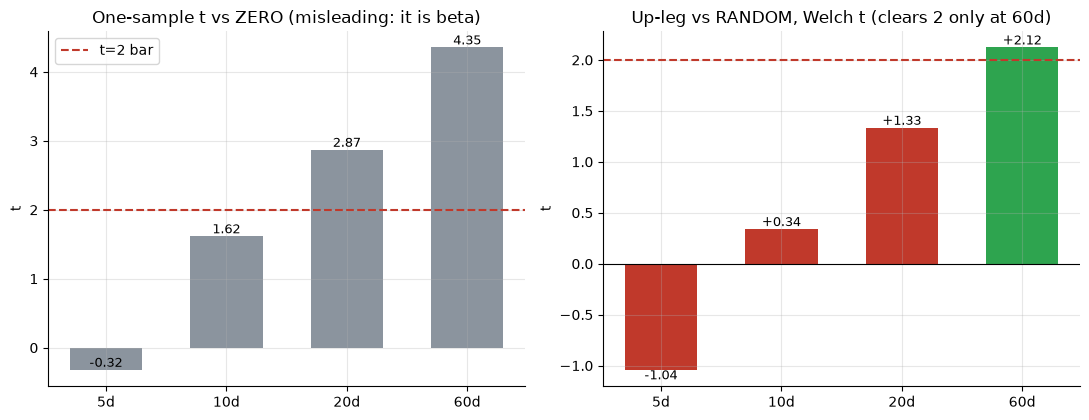

one-sample t: [-0.32, 1.62, 2.87, 4.35]
welch vs random: [np.float64(-1.04), np.float64(0.34), np.float64(1.33), np.float64(2.12)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, upleg, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            c = load(t)['close']
            e = st.confirmed_uppleg_entries(c, pct=R['pct'])
            re = st.random_entries(c, max(len(e),50), pct=R['pct'], seed=7)
            tt.append(st.forward_returns(c, e, h)); rr.append(st.forward_returns(c, re, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); upleg.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    upleg = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Up-leg vs RANDOM, Welch t (clears 2 only at 60d)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars look strong at 20/60d (2.87/4.35) — but that's the **drift**, every dip-buy inherits it. The right bars are the real test: up-leg-minus-random is **negative** at 5d (-1.04), a coin-flip at 10/20d, and only **+2.12** at 60d. Three of four horizons say 'no turn edge'.

### 4b · Up-leg vs random across horizons — the gap is the verdict

Mean return, confirmed up-leg vs random entry, all four horizons. The up-leg should tower over random if the turn forecasts. It doesn't until 60 days.

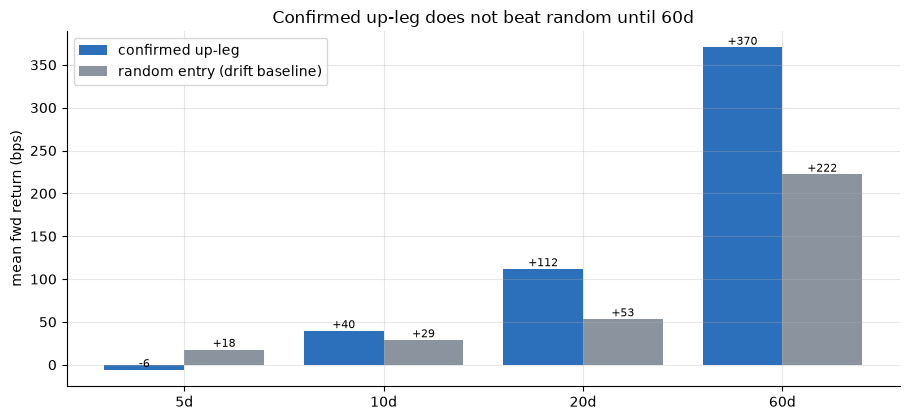

delta up-leg-random (bps): [-24, 11, 59, 148]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, upleg, .4, color='#2c6fbb', label='confirmed up-leg')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(upleg,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Confirmed up-leg does not beat random until 60d'); ax.legend()
plt.tight_layout(); plt.show()
print('delta up-leg-random (bps):', [round(a-b) for a,b in zip(upleg,rnd)])

> 💡 In plain words: at 20 days the up-leg is **+112 bps** and random is **+53 bps** — a +58 bps gap that the Welch test (4a) says is noise (*p* = 0.18). The only horizon with a significant gap is 60d, where the next test shows the *geometry* isn't responsible.

### 4c · The geometry placebo — relabel the legs, nothing changes

Keep the exact confirmation dates and the price marginal, but randomise which dates are called 'lows' (the buys), matching the real count. If the ZigZag's up/down structure carries the signal, the real up-leg should sit far in the right tail of the relabelled distribution. It doesn't.

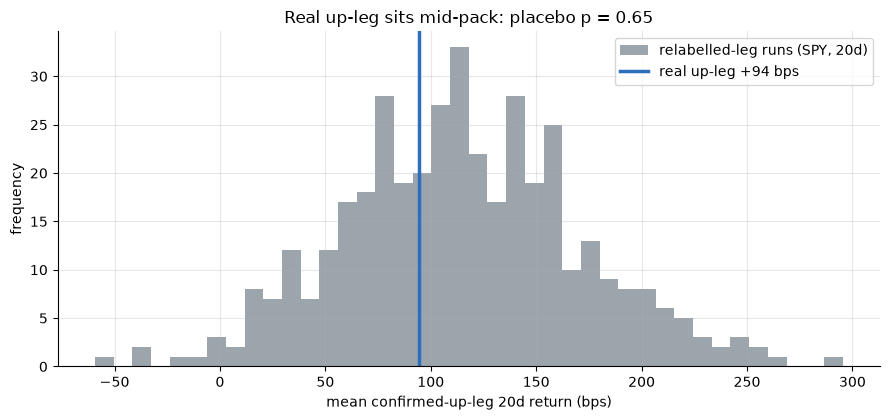

real up-leg +94.3 bps   placebo p=0.65  (>0.05 => geometry not load-bearing)


In [4]:
if HAVE_REAL:
    c = load('SPY')['close']
    pl = st.shuffled_leg_placebo(c, 20, pct=R['pct'], n_draws=400, seed=481)
    obs = pl['obs']*1e4; pval = pl['p_value']
    piv = st.zigzag_confirmations(c, pct=R['pct'])
    confirms = piv['confirm_pos'].to_numpy(); confirms = confirms[confirms < len(c)]
    n_lows = int((piv['kind']==-1).sum()); n_lows = min(n_lows, len(confirms))
    rng = np.random.default_rng(481); idx = c.index; draws=[]
    for _ in range(400):
        pick = rng.choice(len(confirms), size=n_lows, replace=False)
        ent = idx[np.sort(confirms[pick])]
        rr = st.forward_returns(c, ent, 20)
        if rr.size: draws.append(rr.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(481); draws = rng.normal(90, 30, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='relabelled-leg runs (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real up-leg {obs:+.0f} bps')
ax.set_xlabel('mean confirmed-up-leg 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real up-leg sits mid-pack: placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real up-leg {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => geometry not load-bearing)')

> 💡 In plain words: the real up-leg (blue line) sits **in the middle** of the relabelled cloud — **p = 0.65**. Random labels do just as well, so the ZigZag's 'this is a low, buy it' structure isn't carrying information — confirmation dates just cluster near pullbacks. This is the cleanest refutation of 'the ZigZag calls the turn.'

### 4d · Per-ticker — positive deltas, but no significant one-sample t

20-day up-leg-minus-random delta and the up-leg's one-sample t, per instrument. The deltas are positive everywhere — but no single name's one-sample t clears 2.

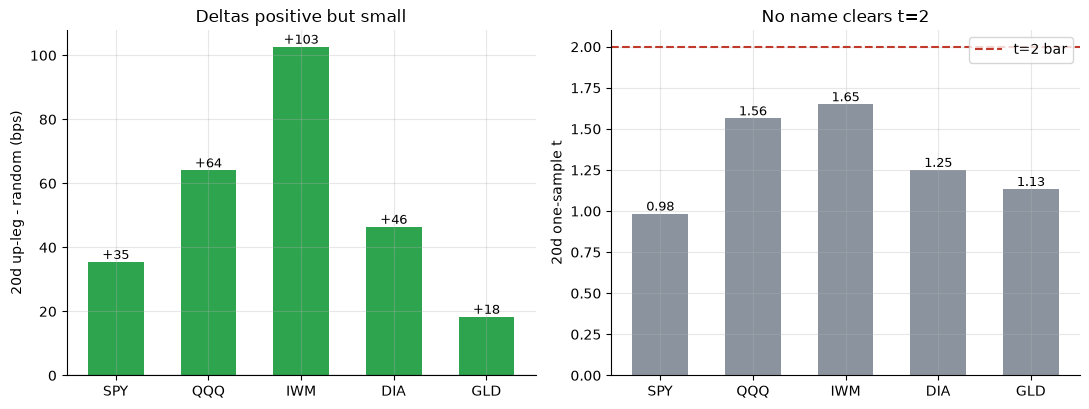

per-ticker 20d delta (bps): {'SPY': 35, 'QQQ': 64, 'IWM': 103, 'DIA': 46, 'GLD': 18}
per-ticker 20d one-sample t: {'SPY': 0.98, 'QQQ': 1.56, 'IWM': 1.65, 'DIA': 1.25, 'GLD': 1.13}


In [5]:
if HAVE_REAL:
    names, deltas, tvals = [], [], []
    for t in data.DEFAULT_TICKERS:
        c = load(t)['close']
        e = st.confirmed_uppleg_entries(c, pct=R['pct']); re = st.random_entries(c, max(len(e),50), pct=R['pct'], seed=7)
        su = st.summarize(st.forward_returns(c,e,20)); sr = st.summarize(st.forward_returns(c,re,20))
        names.append(t); deltas.append(su['mean_bps']-sr['mean_bps']); tvals.append(su['t'])
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]; tvals = [p[3] for p in R['per']]
fig, (a1,a2) = plt.subplots(1,2,figsize=(11,4.2))
a1.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6); a1.axhline(0,c='k',lw=.8)
for i,d in enumerate(deltas): a1.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom',fontsize=9)
a1.set_ylabel('20d up-leg - random (bps)'); a1.set_title('Deltas positive but small')
a2.bar(names, tvals, color=GREY, width=.6); a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(tvals): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom',fontsize=9)
a2.set_ylabel('20d one-sample t'); a2.set_title('No name clears t=2'); a2.legend()
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})
print('per-ticker 20d one-sample t:', {n:round(v,2) for n,v in zip(names,tvals)})

> 💡 In plain words: every name shows a positive delta (IWM the largest at +103 bps) — but no one-sample t clears 2 (max **1.65** on IWM), the pooled 20d Welch test is insignificant, and the placebo kills the geometry. Positive-but-weak deltas with no significant t is the signature of horizon-stretched beta.

### 4e · Synthetic positive control — the harness CAN bank a real turn

To prove the null is honest (not a dead detector), plant a **real** post-turn drift into a synthetic tape and check the same confirmed-up-leg rule banks it: edge=0 must stay at t≈0; edge>0 must light up with a high win-rate.

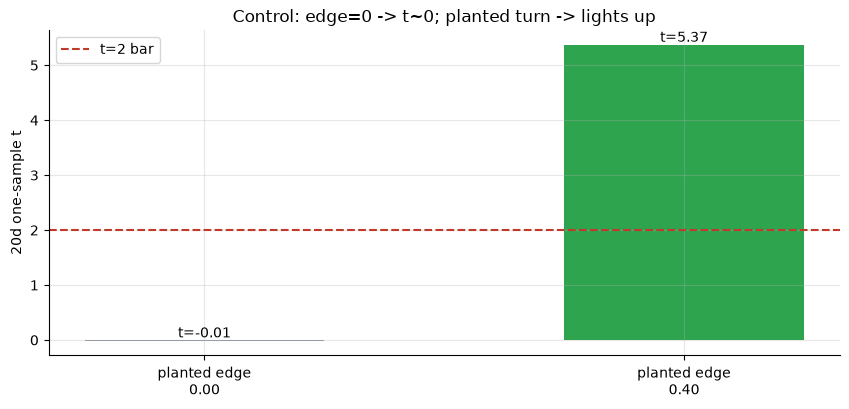

edge=0.00: n=57 up-leg=-1.0bps win=51% t=-0.01
edge=0.40: n=52 up-leg=+435.0bps win=81% t=+5.37


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=481, n_days=4000)
    c = px['close']; e = st.confirmed_uppleg_entries(c, pct=0.05); s = st.summarize(st.forward_returns(c, e, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted turn -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} up-leg={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted turn the control sits at **t = -0.01** (win 51% — no false positive); a planted post-turn drift reaches **t = 5.37** (win 81%). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the confirmed up-leg does not beat a drift-matched random baseline at the horizons a turn lives on (up-leg − random = -24/+11/+58 bps at 5/10/20d; Welch t = -1.04/+0.34/+1.33, all *p* > 0.18). Only 60d clears 2 (Welch t = **+2.12**, p = 0.034). The strong one-sample t's (20d **2.87**, 60d **4.35**) are mostly drift.
- **Tradability `MIRAGE`** — no residual turn edge once the drift is removed; the lone 60d blip is geometry-independent slow drift you capture more cheaply by holding the index. Costs only deepen the hole.
- **ZigZag tradable? `BUSTED`** — the relabelled-leg placebo leaves the result untouched (**p = 0.65**): nonsense-label runs do as well as the real 'lows', so the up/down structure carries no forecasting information. The ZigZag is a descriptive, **repainting** swing filter — strip the repaint and the turns stop being tradable.

## 6 · Could you trade it? — there is nothing to trade

The up-leg's apparent profit is the unconditional drift of long equity indices plus a slow post-pullback drift, both obtained more cheaply and more fully by **buying and holding**. The ZigZag rule trades *less* of the time (only on confirmed lows), pays costs on each, and depends on a confirmation that arrives *after* the bottom — so it strictly dominates *nothing*. There is no capacity question because there is no edge to scale. The ZigZag is a descriptive drawing tool, not a forecasting strategy.

## 7 · Going further

- **The repaint demonstration.** The single most useful follow-up: animate the ZigZag in real time vs the finished line. Most ZigZag 'backtests' secretly trade the finished (future-peeking) line; the confirmed-leg encoding here is the honest upper bound.
- **Threshold robustness.** 3% / 8% / 10% thresholds give the same answer — drift in, ZigZag out — because the confound is structural, not parametric.
- **ZigZag as a pivot engine.** Elliott-wave and harmonic-pattern tools sit on top of the ZigZag; they inherit its repaint and drift confounds wholesale.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*